# Low-mass threshold comparison plot

Baseline energy resolution and dark-matter mass reach vs experiment, sourced from `configs/config_low_mass_th.py`.

In [7]:
import os
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator

sys.path.insert(0, os.path.abspath("../configs"))
from config_low_mass_th import sigma_e_summary, convert_sigma_e_df

plt.rcParams.update({"font.size": 14})


## Plot helpers

In [26]:
SENSOR_MARKERS = {
    "TES": "s",
    "MKID": "o",
    "QUBIT": "^",
}


def marker_for(sensor):
    """Return the marker shape associated with a sensor type."""
    return SENSOR_MARKERS.get(sensor, "x")


SENSOR_LABELS = {
    "TES": "Transition Edge Sensor",
}


def sensor_legend_handles():
    """Build legend handles for each sensor type's marker shape."""
    return [
        Line2D([0], [0], marker=marker, color="w", markerfacecolor="lightgray",
               markeredgecolor="black", markersize=10, label=SENSOR_LABELS.get(sensor, sensor))
        for sensor, marker in SENSOR_MARKERS.items()
    ]


YEAR_PATTERN = re.compile(r"(19|20)\d{2}")


def get_year(exp_name):
    """Extract the year embedded in an experiment's title (the dict key)."""
    match = YEAR_PATTERN.search(exp_name)
    return int(match.group()) if match else None


LABEL_OFFSETS = {
    "SuperCDMS CPD 2021": (0, -10, "center", "top"),
    "TESSERACT 2025": (0, -10, "center", "top"),
}


def label_offset_for(exp_name):
    """Return (dx, dy, ha, va) placement for an experiment's text label,
    falling back to below-and-left of the marker."""
    return LABEL_OFFSETS.get(exp_name, (-8, -10, "right", "top"))


def line_group_for(exp_name, sensor):
    """Return the connection group for a point, or None if it should not be
    connected by a line. All TES points are connected as one group; within
    MKID, only the KIPM family (KIPM, PAA-KIPM) is connected -- BULLKID and
    other MKID/QUBIT experiments are left unconnected."""
    if sensor == "TES":
        return "TES"
    if "KIPM" in exp_name:
        return "KIPM"
    return None


## `plot_dm_thresholds`

In [35]:
def plot_dm_thresholds(plot_dir):
    plot_df = convert_sigma_e_df()

    fig, ax = plt.subplots(figsize=(10, 6))

    points_by_group = {}
    for exp_name, row in plot_df.iterrows():
        year = get_year(exp_name)

        if not pd.isna(row.get("baseline_sigma_e_obs", np.nan)):
            val = row["baseline_sigma_e_obs"]*1e3
            color = "tab:blue"
        else:
            val = row["baseline_sigma_e_exp"]*1e3
            color = "tab:orange"

        sensor = row.get("sensor", "")
        marker = marker_for(sensor)

        ax.scatter(year, val, color=color, marker=marker, s=140,
                   edgecolor='black', zorder=3)

        # assume val is already in meV (like your code val = ... * 1e3)
        val_meV = val
        if val_meV >= 10*1e3:
            val_disp = val_meV / 1e3
            unit = "eV"
        else:
            val_disp = val_meV
            unit = "meV"

        dx, dy, ha, va = label_offset_for(exp_name)
        ax.annotate(
            f"{exp_name}\n{val_disp:.0f} {unit}",
            (year, val),
            textcoords="offset points", xytext=(dx, dy),
            va=va, ha=ha, fontsize=10)

        group = line_group_for(exp_name, sensor)
        if year is not None and group is not None:
            points_by_group.setdefault(group, []).append((year, val))

    # Connect points within the same line group (e.g. KIPM family), ordered by year
    for group, pts in points_by_group.items():
        if len(pts) < 2:
            continue
        pts = sorted(pts, key=lambda p: p[0])
        years, vals = zip(*pts)
        ax.plot(years, vals, linestyle="--", color="gray", linewidth=1.5, zorder=2)

    # --- Axis labels, grids, legends ---
    ax.set_title("Phonon-Mediated Dark Matter–Nucleon Detectors")
    ax.set_xlabel("Year")
    ax.set_ylabel(r"Deposited energy resolution [meV]")
    ax.set_yscale('log')
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
    ax.set_ylim(1e-1, 1e7)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.margins(x=0.15)

    sensor_handles = sensor_legend_handles()
    oe_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor="tab:blue",
               markeredgecolor='black', markersize=10, label="Observed"),
        Line2D([0], [0], marker='o', color='w', markerfacecolor="tab:orange",
               markeredgecolor='black', markersize=10, label="Expected"),
    ]
    leg1 = ax.legend(handles=oe_handles, loc="upper right", frameon=False)
    ax.add_artist(leg1)
    ax.legend(handles=sensor_handles, loc="upper left", frameon=False)

    def sigma_to_mchi(sigma_e_meV):
        """
        Convert baseline sigma_E from meV -> dark matter threshold mass in MeV.
        """
        sigma_e_ev = sigma_e_meV * 1e-3        # meV -> eV
        mchi_ev = sigma_e_ev * (1e6 / 0.010)   # scaling in eV
        return mchi_ev / 1e6                   # eV -> MeV

    def mchi_to_sigma(mchi_meV):
        """
        Inverse: convert m_chi in MeV back to sigma_E in meV.
        """
        mchi_ev = mchi_meV * 1e6               # MeV -> eV
        sigma_e_ev = mchi_ev * 0.010 / 1e6     # invert scaling, result in eV
        return sigma_e_ev * 1e3                # eV -> meV

    secax = ax.secondary_yaxis("right", functions=(sigma_to_mchi, mchi_to_sigma))
    secax.set_ylabel(r"Dark Matter Mass Reach $m_\chi$ [MeV]", labelpad=12)
    secax.set_yscale('log')
    secax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

    fig.tight_layout()

    # Show the figure in the notebook before saving it
    plt.show()

    # Save figure
    save_dir = os.path.dirname(f"{plot_dir}")
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
    fig.savefig(plot_dir + ".pdf", dpi=300, bbox_inches='tight')
    fig.savefig(plot_dir + ".png", dpi=300, bbox_inches='tight')
    plt.close(fig)


## Run

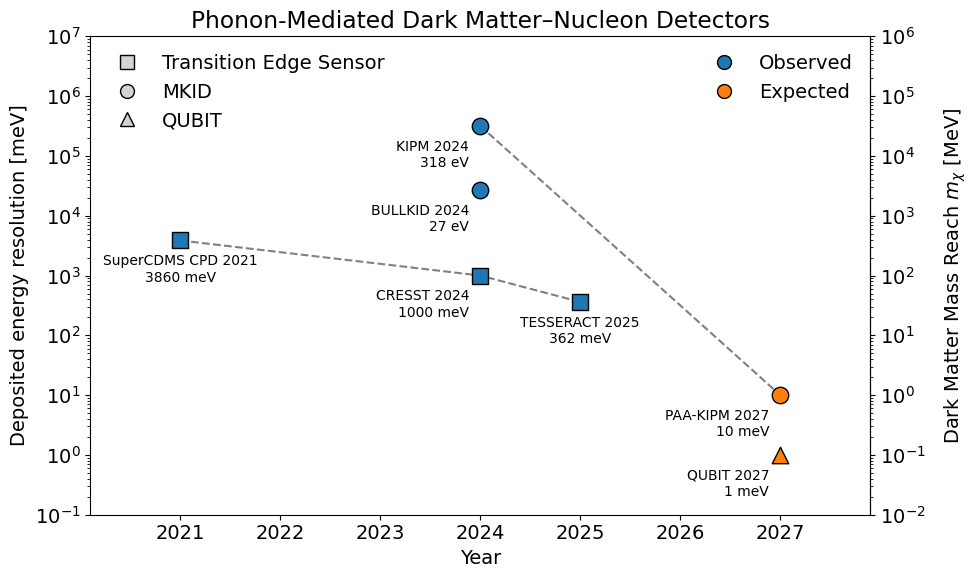

In [36]:
plot_dm_thresholds("../plots/low_mass_th/low_mass_th")
